In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from matplotlib import gridspec
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import skfda
from skfda.preprocessing.dim_reduction.feature_extraction import FPCA
plt.rcParams.update({'font.size': 22})
# from bumps.names import Parameter
# from bumps.fitters import fit

# from sasmodels.core import load_model
# from sasmodels.bumps_model import Model, Experiment

# import bumps
# import sasmodels

In [26]:
def read_DAT_file(name):
    with open(name) as pdbfile:
        q = []
        I = []
        dI = []
        start = 10000
        for i,line in enumerate(pdbfile):
            if 'q(A-1)' in line:
                start = i
            if i > start: 
                splitted_line = [line[0:20], line[23:50], line[50:]]
                q.append(splitted_line[0])
                I.append(splitted_line[1])
                dI.append(splitted_line[2])
        q = np.array([float(i) for i in q])
        I = np.array([float(i) for i in I])
        dI = np.array([float(i) for i in dI])
        data = np.hstack((q.reshape(-1,1), I.reshape(-1,1), dI.reshape(-1,1)))
    return data

def convert_data(data, model):
    model_x = model[:,0]
    model_y = model[:,1]
    index = np.linspace(0, len(model_x)-1, len(model_x)) 
    model_q_new = []
    model_I_new = []
    for i in range(len(data)):
        data_q = data[i,0]
        array = np.abs(model_x - data_q)
        array = np.hstack((array.reshape(-1,1), index.reshape(-1,1)))
        array = array[np.argsort(array[:, 0])]
        loc = int(array[0,1])
        model_q_new.append(model_x[loc])
        model_I_new.append(model_y[loc])
    q = np.array(model_q_new).reshape(-1,1)
    I = np.array(model_I_new).reshape(-1,1)
    new_model_data = np.hstack((q, I))
    return new_model_data


def normalize_scattering_curves(q, I1, I2, q_min, q_max):
    """
    Normalizes the second scattering curve to match the first within the q-range [q_min, q_max].

    Parameters:
        data (np.ndarray): 2D array with shape (N, 3), where
                           - column 0: q values,
                           - column 1: intensity of curve 1,
                           - column 2: intensity of curve 2
        q_min (float): lower bound of q-range for normalization
        q_max (float): upper bound of q-range for normalization

    Returns:
        np.ndarray: New array with same shape as input, with column 2 normalized
    """
    # Mask to select points within the given q-range
    mask = (q >= q_min) & (q <= q_max)
    if not np.any(mask):
        raise ValueError("No data points found within the specified q-range.")
    # Calculate normalization factor
    scale_factor = np.mean(I1[mask]) / np.mean(I2[mask])
    # Apply normalization
    I2_normalized = I2 * scale_factor
    # Return the combined array
    return I2_normalized


def calculate_structure_factor(data0, data2, q_min, q_max, plot):
    new_data_2 = convert_data(data0, data2)
    fig, ax = plt.subplots(figsize=(7,7))
    normalized_data = normalize_scattering_curves(new_data_2[:,0], new_data_2[:,1], data0[:,1], q_min, q_max)
    plt.scatter(data0[:,0], normalized_data, color = 'blue', label = 'data0')
    plt.scatter(new_data_2[:,0], new_data_2[:,1], color = 'red', label = 'data2')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel('Intensity (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
    if plot == False:
        plt.close()
    structure_factor = new_data_2[:,1]/((normalized_data))
    structure_factor = np.hstack((new_data_2[:,0].reshape(-1,1), structure_factor.reshape(-1,1)))
    return structure_factor


## Load Structure Factor Data

In [27]:
sq_list = []

path = '../Data/Simulations_all/Bridge 20 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

path = '../Data/Simulations_all/Bridge 40 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

path = '../Data/Simulations_all/Bridge 80 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
        #print(path2)
        struc_factor = np.load(path2)
        sq_list.append(struc_factor)

# path = '../Data/Simulations_all/Dense_Agg Structure Factor/'
# filenames = os.listdir(path)
# for i in range(len(filenames)):
#     filenames1 = os.listdir(path + filenames[i])
#     path1 = path + filenames[i] + '/' + filenames1[0] + '/'
#     filenames2 = os.listdir(path1)
#     if 'scattering_data' in filenames2:
#         path2 = path1 + filenames2[-2] + '/average_structure_factor.npy'
#         #print(path2)
#         struc_factor = np.load(path2)
#         sq_list.append(struc_factor)

In [28]:
for i in range(len(sq_list)):
    if i == 0:
        sq_array = sq_list[0][:,1].reshape(-1,1)
    else:
        sq_array = np.hstack((sq_array, sq_list[i][:,1].reshape(-1,1))) 
q_values = sq_list[0][100:300,0]
sq_array = sq_array[100:300,:]

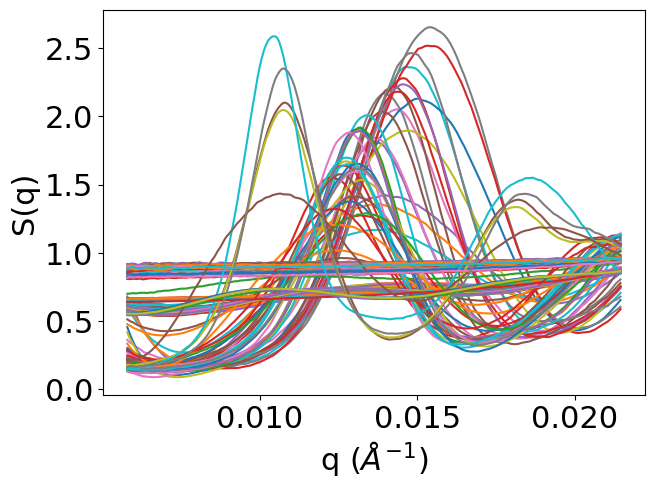

In [31]:
fig, ax = plt.subplots(figsize=(7,5))
plt.rcParams.update({'font.size': 20})
for i in range(sq_array.shape[0]):
#for i in range(200):
    plt.plot(q_values, sq_array[:,i])
    plt.xlabel("q ($\\AA^{-1}$)")
    plt.ylabel("S(q)")

Loaded 274 samples, 200 q-points


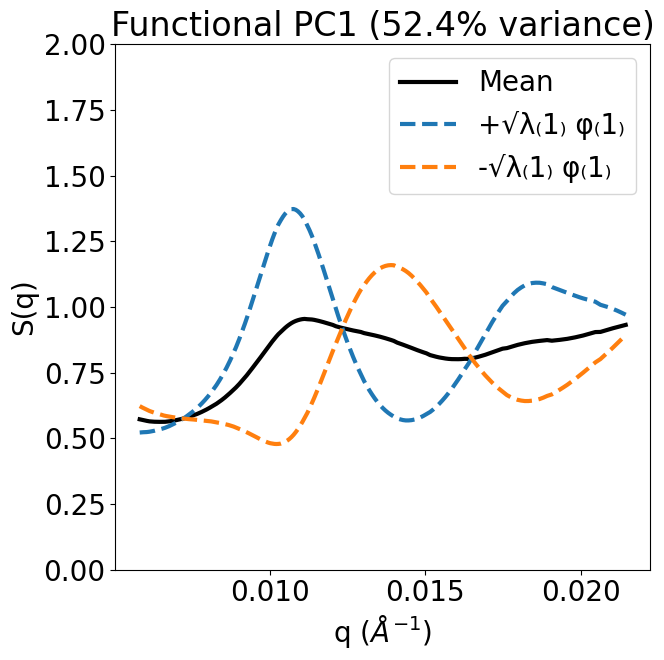

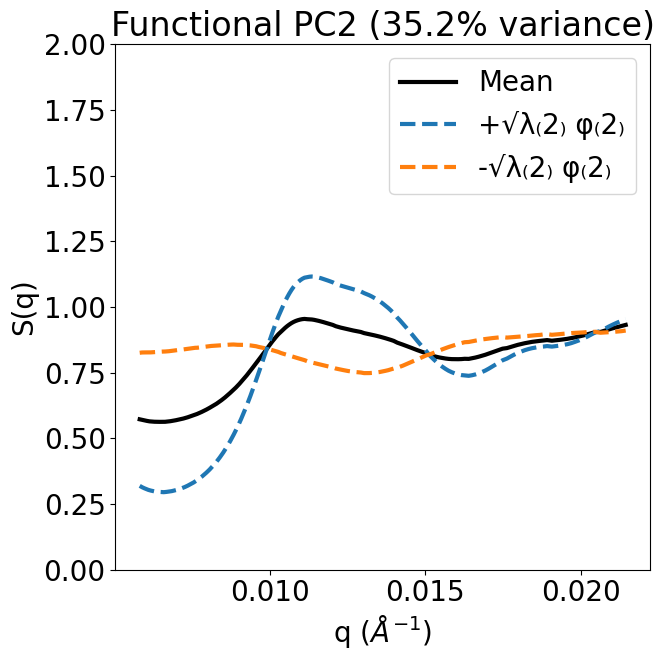

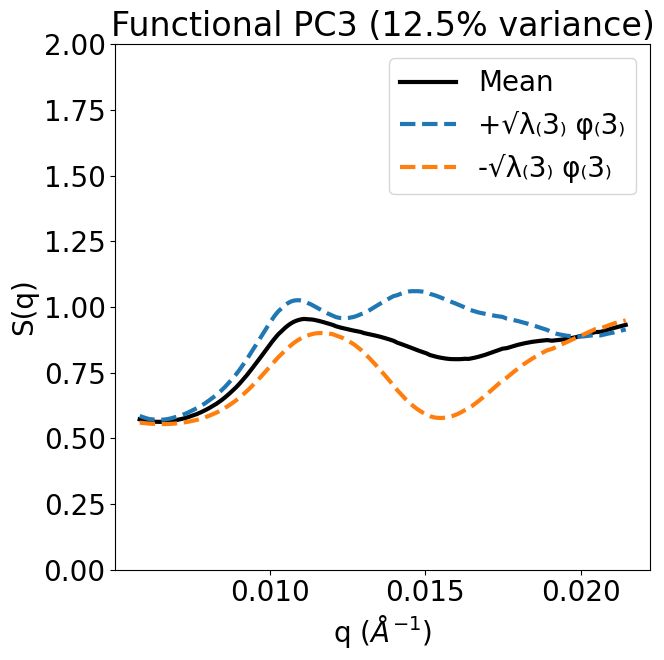

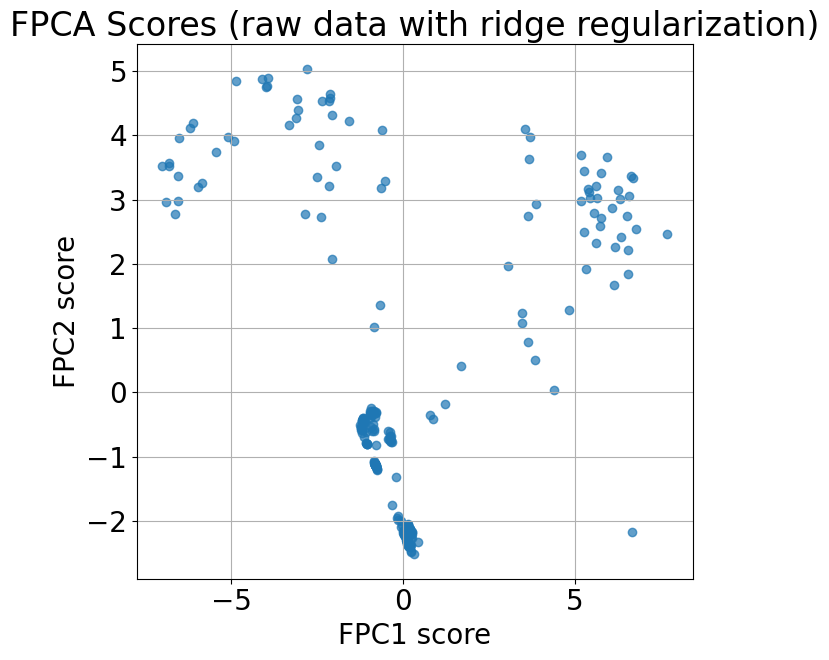

Explained variance ratios: [0.524 0.352 0.125]
Cumulative variance explained: [0.524 0.875 1.   ]


In [32]:
from numpy.linalg import eigh
plt.rcParams.update({'font.size': 20})
# Ensure each row is a sample (function)
if sq_array.shape[0] == q_values.shape[0]:
    sq_array = sq_array.T

n_samples, n_q = sq_array.shape
print(f"Loaded {n_samples} samples, {n_q} q-points")

# ---------------------------------------------------------------------
# 2. Preprocess: use log(q) and center data
# ---------------------------------------------------------------------
log_q = (q_values)
mean_curve = np.mean(sq_array, axis=0)
X_centered = sq_array - mean_curve  # subtract mean function

# ---------------------------------------------------------------------
# 3. Compute and regularize covariance matrix
# ---------------------------------------------------------------------
C = np.cov(X_centered, rowvar=False)

# Add ridge regularization to ensure positive definiteness
ridge = 1e-6 * np.eye(C.shape[0])
C_reg = C + ridge

# ---------------------------------------------------------------------
# 4. Eigen-decomposition of covariance matrix
# ---------------------------------------------------------------------
eigvals, eigvecs = eigh(C_reg)              # ascending order
idx = np.argsort(eigvals)[::-1]             # sort descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# ---------------------------------------------------------------------
# 5. Keep first few principal components
# ---------------------------------------------------------------------
n_components = 3
eigvals = eigvals[:n_components]
eigvecs = eigvecs[:, :n_components]
explained_ratio = eigvals / eigvals.sum()
scores = X_centered @ eigvecs               # (n_samples × n_components)

# ---------------------------------------------------------------------
# 6. Plot mean ± √λ * φ_k(q)
# ---------------------------------------------------------------------
for i in range(n_components):
    sd = np.sqrt(eigvals[i])
    pc = eigvecs[:, i]
    plt.figure(figsize=(7, 7))
    plt.plot(log_q, mean_curve, 'k', label='Mean', linewidth=3)
    plt.plot(log_q, mean_curve + sd * pc, '--', label=f'+√λ₍{i+1}₎ φ₍{i+1}₎', linewidth=3)
    plt.plot(log_q, mean_curve - sd * pc, '--', label=f'-√λ₍{i+1}₎ φ₍{i+1}₎', linewidth=3)
    plt.xlabel("q ($\\AA^{-1}$)")
    plt.ylabel("S(q)")
    plt.ylim([0,2])
    plt.title(f"Functional PC{i+1} ({explained_ratio[i]*100:.1f}% variance)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 7. FPCA score plot (FPC1 vs FPC2)
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.7)
plt.xlabel("FPC1 score")
plt.ylabel("FPC2 score")
plt.title("FPCA Scores (raw data with ridge regularization)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 8. Print variance explained
# ---------------------------------------------------------------------
print("Explained variance ratios:", np.round(explained_ratio, 3))
print("Cumulative variance explained:", np.round(np.cumsum(explained_ratio), 3))

In [33]:

# Convert to a DataFrame for clarity
scores_df = pd.DataFrame(scores, columns=[f'FPC{i+1}' for i in range(scores.shape[1])])
print(scores_df.head())

       FPC1      FPC2      FPC3
0  0.066227 -2.247753  0.708711
1 -1.203737 -0.579027 -1.000436
2 -0.791254 -1.148009 -1.150366
3 -1.155897 -0.408518 -1.244537
4 -2.850732  2.781681  1.776634


## Load Inputs

In [34]:
path = '../Data/Simulations_all/Bridge 20 Structure Factor/'
filenames = os.listdir(path)
input_params_array = np.array([0])
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path + filenames[i] + '/input_params.csv'
        input_params = pd.read_csv(path2).values
        input_params = input_params.reshape(1,-1)
        if input_params_array.all() == 0:
            input_params_array = input_params
        else:
            input_params_array = np.vstack((input_params_array, input_params))

path = '../Data/Simulations_all/Bridge 40 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path + filenames[i] + '/input_params.csv'
        input_params = pd.read_csv(path2).values
        input_params = input_params.reshape(1,-1)
        if input_params_array.all() == 0:
            input_params_array = input_params
        else:
            input_params_array = np.vstack((input_params_array, input_params))
            
path = '../Data/Simulations_all/Bridge 80 Structure Factor/'
filenames = os.listdir(path)
for i in range(len(filenames)):
    filenames1 = os.listdir(path + filenames[i])
    path1 = path + filenames[i] + '/' + filenames1[0] + '/'
    filenames2 = os.listdir(path1)
    if 'scattering_data' in filenames2:
        path2 = path + filenames[i] + '/input_params.csv'
        input_params = pd.read_csv(path2).values
        input_params = input_params.reshape(1,-1)
        if input_params_array.all() == 0:
            input_params_array = input_params
        else:
            input_params_array = np.vstack((input_params_array, input_params))
            
# path = '../Data/Simulations_all/Dense_Agg Structure Factor/'
# filenames = os.listdir(path)
# for i in range(len(filenames)):
#     filenames1 = os.listdir(path + filenames[i])
#     path1 = path + filenames[i] + '/' + filenames1[0] + '/'
#     filenames2 = os.listdir(path1)
#     if 'scattering_data' in filenames2:
#         path2 = path + filenames[i] + '/input_params.csv'
#         input_params = pd.read_csv(path2).values
#         input_params = input_params.reshape(1,-1)
#         if input_params_array.all() == 0:
#             input_params_array = input_params
#         else:
#             input_params_array = np.vstack((input_params_array, input_params))
            

In [35]:
#replace n and m with n-m
# n_minus_m = np.abs(input_params_array[:,-2] - input_params_array[:,-1]).reshape(-1,1)
# input_params_array = np.hstack((input_params_array[:,0:3], n_minus_m))

## Fit and Train Model

In [36]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
#import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score

In [37]:
x = input_params_array
y1 = np.array(scores_df.values[:,0]).reshape(-1,1)
y2 = np.array(scores_df.values[:,1]).reshape(-1,1)
y3 = np.array(scores_df.values[:,2]).reshape(-1,1)

In [38]:
scaler = MinMaxScaler()
x = scaler.fit(x).transform(x)

In [39]:
y1 = scaler.fit(y1).transform(y1)
y2 = scaler.fit(y2).transform(y2)
y3 = scaler.fit(y2).transform(y3)

Using 205 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 69/69 [00:01<00:00, 36.97it/s]


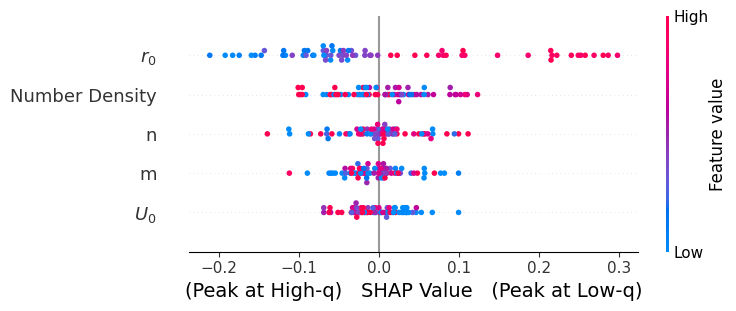

In [40]:
X_train, X_test, y_train, y_test = train_test_split(x, y1,
                                            test_size=0.25,
                                            random_state=1)

rbf = ConstantKernel(1.0) * RBF(length_scale=.1)
gpc = GaussianProcessRegressor(kernel=rbf)
model = gpc.fit(X_train, y_train.ravel())
X_test = pd.DataFrame(X_test, columns = ['Number Density', '$U_{0}$', '$r_{0}$', 'n','m'])
# shap_values = shap.TreeExplainer(model).shap_values(X_test)
# shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X_test)
fig, ax = plt.gcf(), plt.gca()
explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
ax.set_xlabel("(Peak at High-q)   SHAP Value   (Peak at Low-q)", fontsize=14)
#plt.savefig('../../Figures/230214/Shap_Plate_Thickness.png')
plt.show()

Using 205 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 69/69 [00:01<00:00, 40.92it/s]


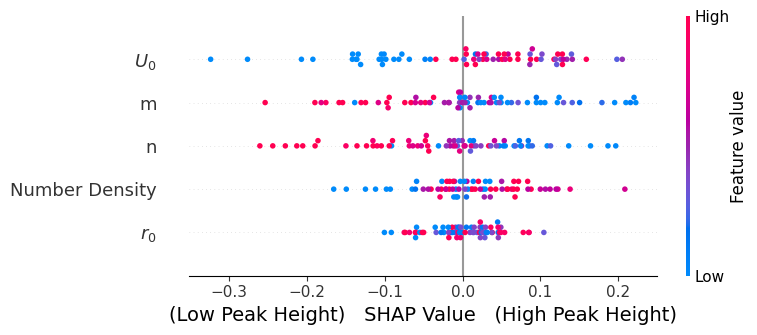

In [41]:
X_train, X_test, y_train, y_test = train_test_split(x, y2,
                                            test_size=0.25,
                                            random_state=1)

rbf = ConstantKernel(1.0) * RBF(length_scale=.1)
gpc = GaussianProcessRegressor(kernel=rbf)
model = gpc.fit(X_train, y_train.ravel())


plt.rcParams.update({'font.size': 12})
X_test = pd.DataFrame(X_test, columns = ['Number Density', '$U_{0}$', '$r_{0}$', 'n','m'])
# shap_values = shap.TreeExplainer(model).shap_values(X_test)
# shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X_test)
fig, ax = plt.gcf(), plt.gca()
explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
ax.set_xlabel("(Low Peak Height)   SHAP Value   (High Peak Height)", fontsize=14)
#plt.savefig('../../Figures/230214/Shap_Plate_Thickness.png')
plt.show()

Using 205 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


100%|██████████| 69/69 [00:01<00:00, 46.38it/s]


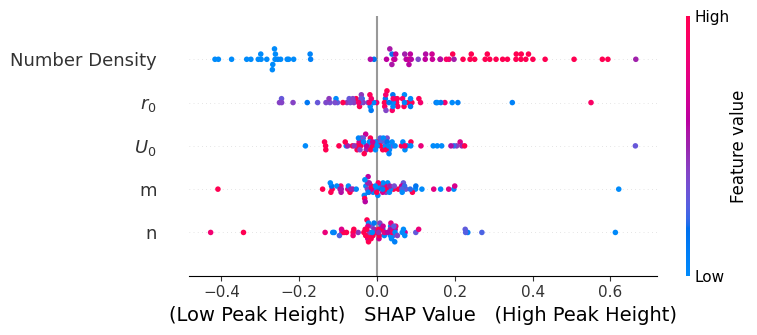

In [42]:
X_train, X_test, y_train, y_test = train_test_split(x, y3,
                                            test_size=0.25,
                                            random_state=1)

rbf = ConstantKernel(1.0) * RBF(length_scale=.1)
gpc = GaussianProcessRegressor(kernel=rbf)
model = gpc.fit(X_train, y_train.ravel())


plt.rcParams.update({'font.size': 12})
X_test = pd.DataFrame(X_test, columns = ['Number Density', '$U_{0}$', '$r_{0}$', 'n','m'])
# shap_values = shap.TreeExplainer(model).shap_values(X_test)
# shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X_test)
fig, ax = plt.gcf(), plt.gca()
explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
ax.set_xlabel("(Low Peak Height)   SHAP Value   (High Peak Height)", fontsize=14)
#plt.savefig('../../Figures/230214/Shap_Plate_Thickness.png')
plt.show()